# U-Net — Pneumonia Segmentation & Classification

Trains a residual U-Net on the RSNA dataset for simultaneous **segmentation** (pixel-level mask) and **classification** (healthy vs pneumonia).

**Outputs saved to `/kaggle/working/`:**
- `model_unet_full.keras` — full multi-input model (image + tabular)
- `model_unet_inference.keras` — image-only model (ready for web app)
- `history_unet.csv` — training logs

> **Runtime → Change runtime type → T4 GPU** before running.

---

## 1. Imports

In [1]:
import os, sys, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Conv2DTranspose,
    UpSampling2D, concatenate, Add, Dropout, Flatten,
    Dense, BatchNormalization, LeakyReLU, Reshape,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryIoU

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

2026-06-21 20:29:44.534142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782073784.779107      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782073784.849133      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782073785.434278      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782073785.434319      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782073785.434322      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


## 2. Dataset Paths

This notebook uses the **[RSNA Pneumonia Processed Dataset](https://www.kaggle.com/datasets/)** — it contains pre-generated segmentation masks derived from the original RSNA bounding boxes.

In [2]:
import os

OUTPUT_DIR = "/kaggle/working/"

# Walk the entire /kaggle/input/ tree to find stage2_train_metadata.csv
INPUT_DIR = None
IMAGES_DIR = None
MASKS_DIR = None

for root, dirs, files in os.walk("/kaggle/input/"):
    if "stage2_train_metadata.csv" in files:
        INPUT_DIR = root
    for d in dirs:
        if d == "Images":
            IMAGES_DIR = os.path.join(root, d)
        elif d == "Masks":
            MASKS_DIR = os.path.join(root, d)

if INPUT_DIR is None:
    print("\nAvailable datasets in /kaggle/input/:")
    try:
        for d in os.listdir("/kaggle/input/"):
            print(f"  - {d}")
    except FileNotFoundError:
        pass
    raise RuntimeError(
        "Could not find 'stage2_train_metadata.csv' in /kaggle/input/. "
        "Make sure you've added the 'RSNA Pneumonia Processed Dataset' via "
        "the 'Add Data' button on the right."
    )

# Ensure trailing slashes for string concatenation later
INPUT_DIR  = INPUT_DIR.rstrip("/") + "/"
IMAGES_DIR = IMAGES_DIR.rstrip("/") + "/" if IMAGES_DIR else INPUT_DIR + "Training/Images/"
MASKS_DIR  = MASKS_DIR.rstrip("/") + "/" if MASKS_DIR else INPUT_DIR + "Training/Masks/"

print(f"\nDataset root: {INPUT_DIR}")
print(f"Images: {IMAGES_DIR} ({len(os.listdir(IMAGES_DIR.rstrip('/')))}) files)")
print(f"Masks:  {MASKS_DIR} ({len(os.listdir(MASKS_DIR.rstrip('/')))}) files)")

# Quick ls
def explore(path, indent=0):
    for item in sorted(os.listdir(path)):
        full = os.path.join(path, item)
        if os.path.isdir(full):
            print("  " * indent + f"[d] {item}/")
            if indent < 1:
                explore(full, indent + 1)
        else:
            print("  " * indent + f"[f] {item}")
explore(INPUT_DIR)


Dataset root: /kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset/
Images: /kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset/Training/Images/ (26684) files)
Masks:  /kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset/Training/Masks/ (26684) files)
[d] Test/
  [f] 0000a175-0e68-4ca4-b1af-167204a7e0bc.png
  [f] 0005d3cc-3c3f-40b9-93c3-46231c3eb813.png
  [f] 000686d7-f4fc-448d-97a0-44fa9c5d3aa6.png
  [f] 000e3a7d-c0ca-4349-bb26-5af2d8993c3d.png
  [f] 00100a24-854d-423d-a092-edcf6179e061.png
  [f] 0015597f-2d69-4bc7-b642-5b5e01534676.png
  [f] 001b0c51-c7b3-45c1-9c17-fa7594cab96e.png
  [f] 0022bb50-bf6c-4185-843e-403a9cc1ea80.png
  [f] 00271e8e-aea8-4f0a-8a34-3025831f1079.png
  [f] 0028450f-5b8e-4695-9416-8340b6f686b0.png
  [f] 002bcde0-d8da-4931-ab04-5d724e30261b.png
  [f] 002fcb77-ef76-4626-ab34-5070f15c20db.png
  [f] 003206b4-bd4a-4684-8d49-76f4cb713a30.png
  [f] 00330f7f-d114-4eb2-9c6e-558eeb3084a1.png
  [f] 00342ae8-ff81-4229-adf6-6a2ab7

## 3. Load & Split Tabular Data

In [3]:
df = pd.read_csv(INPUT_DIR + "stage2_train_metadata.csv")
df = df[df["class"].isin(["Lung Opacity","Normal"])].copy()
df.drop(["x", "y", "width", "height", "modality", "class"], axis=1, inplace=True)
df.drop_duplicates(inplace=True)

# Split
df_train_val, df_test = train_test_split(df, test_size=0.1, stratify=df["Target"], random_state=42)
df_train, df_val   = train_test_split(df_train_val, test_size=0.2, stratify=df_train_val["Target"], random_state=42)

print(f"Train: {df_train.shape},  Val: {df_val.shape},  Test: {df_test.shape}")

Train: (10700, 5),  Val: (2676, 5),  Test: (1487, 5)


Encode categoricals and cap age:

In [4]:
SEX_MAP = {"M": 0, "F": 1}
POS_MAP = {"AP": 0, "PA": 1}

for df_ in [df_train, df_val, df_test]:
    df_["sex"] = df_["sex"].map(SEX_MAP)
    df_["position"] = df_["position"].map(POS_MAP)
    df_["age"] = df_["age"].clip(upper=90)

# Scale age to [0, 1]
scaler = MinMaxScaler()
df_train["age"] = scaler.fit_transform(df_train[["age"]])
df_val["age"]   = scaler.transform(df_val[["age"]])
df_test["age"]  = scaler.transform(df_test[["age"]])

## 4. Hyperparameters

In [5]:
IMAGE_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 20

STEPS_PER_EPOCH = len(df_train) // BATCH_SIZE
VAL_STEPS       = len(df_val) // BATCH_SIZE

print(f"Steps/epoch: {STEPS_PER_EPOCH},  Val steps: {VAL_STEPS}")

Steps/epoch: 167,  Val steps: 41


## 5. Data Pipeline (tf.data)

Functions to load images + masks, augment, and create batched datasets.

In [6]:
def augment_image_and_mask(image, mask):
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, mask


def load_image_and_mask(image_path, mask_path, new_size=(IMAGE_SIZE, IMAGE_SIZE), augment=False):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, new_size)
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, new_size)
    mask = tf.cast(mask, tf.float32)
    mask = tf.where(mask > 0, 1.0, 0.0)

    if augment:
        image, mask = augment_image_and_mask(image, mask)
    return image, mask


def create_dataset(image_paths, mask_paths, variables, targets, batch_size, augment=False, shuffle=False, repeat=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths, variables, targets))

    def map_fn(img_path, mask_path, var, tgt):
        img, mask = load_image_and_mask(img_path, mask_path, augment=augment)
        return (img, var), (mask, tgt)

    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2048)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

Build the three datasets:

In [7]:
def build_paths_and_vars(df):
    return (
        IMAGES_DIR + df["patientId"].astype(str) + ".png",
        MASKS_DIR  + df["patientId"].astype(str) + ".png",
        df[["age", "sex", "position"]].values.astype(np.float32),
        df["Target"].values.astype(np.float32),
    )

img_tr, msk_tr, var_tr, tgt_tr = build_paths_and_vars(df_train)
img_vl, msk_vl, var_vl, tgt_vl = build_paths_and_vars(df_val)
img_te, msk_te, var_te, tgt_te = build_paths_and_vars(df_test)

train_dataset = create_dataset(img_tr, msk_tr, var_tr, tgt_tr, BATCH_SIZE, augment=True,  shuffle=True,  repeat=True)
val_dataset   = create_dataset(img_vl, msk_vl, var_vl, tgt_vl, BATCH_SIZE, augment=False, shuffle=False, repeat=True)
test_dataset  = create_dataset(img_te, msk_te, var_te, tgt_te, BATCH_SIZE, augment=False, shuffle=False)

# Verify shapes
for batch in train_dataset.take(1):
    (imgs, vars_), (masks, tgts) = batch
    print("Images:",     imgs.shape)
    print("Variables:",  vars_.shape)
    print("Masks:",      masks.shape)
    print("Targets:",    tgts.shape)
    break

I0000 00:00:1782073883.735759      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782073883.741894      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Images: (64, 224, 224, 3)
Variables: (64, 3)
Masks: (64, 224, 224, 1)
Targets: (64,)


## 6. EDA

Quick look at class distribution and sample visualisation.

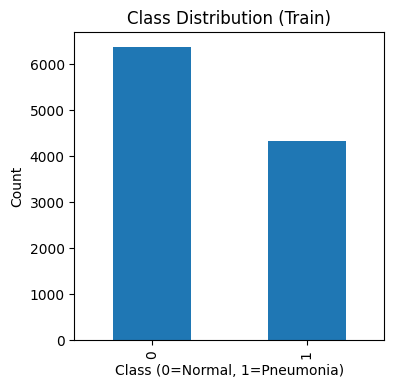

In [8]:
df_train["Target"].value_counts().plot(kind="bar", figsize=(4,4))
plt.title("Class Distribution (Train)")
plt.xlabel("Class (0=Normal, 1=Pneumonia)")
plt.ylabel("Count")
plt.show()

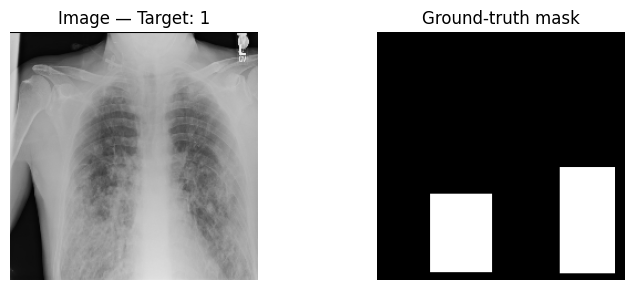

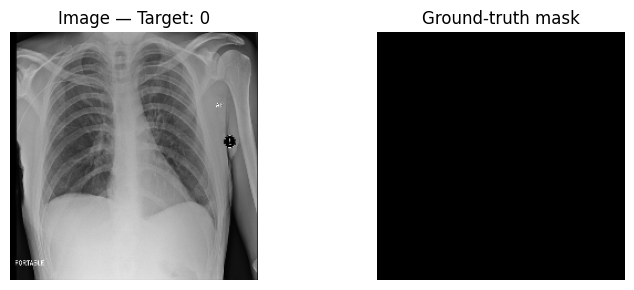

In [9]:
def show_samples(dataset, n=3):
    for (imgs, _), (masks, tgts) in dataset.take(1):
        for i in range(min(n, len(imgs))):
            plt.figure(figsize=(8,3))
            plt.subplot(1,2,1)
            plt.imshow(imgs[i].numpy())
            plt.title(f"Image — Target: {int(tgts[i].numpy())}")
            plt.axis("off")
            plt.subplot(1,2,2)
            plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
            plt.title("Ground-truth mask")
            plt.axis("off")
            plt.tight_layout()
            plt.show()

show_samples(val_dataset, n=2)

## 7. Model — Residual U-Net

Depth-4 U-Net with residual blocks, LeakyReLU, and a multi-modal fusion path for tabular features.

In [10]:
def residual_block(x, n_filters):
    res = BatchNormalization()(x)
    res = Conv2D(n_filters, (3,3), padding="same", use_bias=False)(res)
    res = BatchNormalization()(res)
    res = LeakyReLU(0.1)(res)
    res = Conv2D(n_filters, (3,3), padding="same", use_bias=False)(res)
    res = BatchNormalization()(res)
    res = Add()([res, x])
    res = LeakyReLU(0.1)(res)
    return res


def build_unet(image_size=IMAGE_SIZE):
    img_input = Input(shape=(image_size, image_size, 3), name="image_input")
    var_input = Input(shape=(3,), name="tabular_input")

    # ---- Encoder ----
    c0 = Conv2D(32, (3,3), padding="same", use_bias=False)(img_input)
    c0 = BatchNormalization()(c0)
    c0 = LeakyReLU(0.1)(c0)

    c1 = Conv2D(32, (3,3), padding="same", use_bias=False)(c0)
    c1 = BatchNormalization()(c1)
    c1 = LeakyReLU(0.1)(c1)
    p1 = MaxPooling2D(2)(c1)
    r1 = residual_block(p1, 32)

    c2 = Conv2D(64, (3,3), padding="same", use_bias=False)(r1)
    c2 = BatchNormalization()(c2)
    c2 = LeakyReLU(0.1)(c2)
    p2 = MaxPooling2D(2)(c2)
    r2 = residual_block(p2, 64)

    c3 = Conv2D(128, (3,3), padding="same", use_bias=False)(r2)
    c3 = BatchNormalization()(c3)
    c3 = LeakyReLU(0.1)(c3)
    p3 = MaxPooling2D(2)(c3)
    r3 = residual_block(p3, 128)

    c4 = Conv2D(256, (3,3), padding="same", use_bias=False)(r3)
    c4 = BatchNormalization()(c4)
    c4 = LeakyReLU(0.1)(c4)
    p4 = MaxPooling2D(2)(c4)
    r4 = residual_block(p4, 256)

    # ---- Bottleneck ----
    b = Conv2D(512, (3,3), padding="same", use_bias=False)(p4)
    b = BatchNormalization()(b)
    b = LeakyReLU(0.1)(b)
    b = Conv2D(512, (3,3), padding="same", use_bias=False)(b)
    b = BatchNormalization()(b)
    b = LeakyReLU(0.1)(b)
    b = Dropout(0.3)(b)

    # ---- Decoder ----
    u6 = Conv2DTranspose(256, (2,2), strides=2, padding="same", use_bias=False)(b)
    u6 = BatchNormalization()(u6)
    u6 = LeakyReLU(0.1)(u6)
    m6 = concatenate([c4, u6], axis=3)
    r6 = residual_block(m6, 512)

    u7 = Conv2DTranspose(128, (2,2), strides=2, padding="same", use_bias=False)(r6)
    u7 = BatchNormalization()(u7)
    u7 = LeakyReLU(0.1)(u7)
    m7 = concatenate([c3, u7], axis=3)
    r7 = residual_block(m7, 256)

    u8 = Conv2DTranspose(64, (2,2), strides=2, padding="same", use_bias=False)(r7)
    u8 = BatchNormalization()(u8)
    u8 = LeakyReLU(0.1)(u8)
    m8 = concatenate([c2, u8], axis=3)
    r8 = residual_block(m8, 128)

    u9 = Conv2DTranspose(32, (2,2), strides=2, padding="same", use_bias=False)(r8)
    u9 = BatchNormalization()(u9)
    u9 = LeakyReLU(0.1)(u9)
    m9 = concatenate([c1, u9], axis=3)
    r9 = residual_block(m9, 64)

    # ---- Tabular fusion path ----
    v = Dense(64)(var_input)
    v = BatchNormalization()(v)
    v = LeakyReLU(0.1)(v)
    v = Reshape((1, 1, 64))(v)
    v = UpSampling2D(size=(image_size, image_size))(v)

    merged = concatenate([r9, v], axis=-1)

    # ---- Outputs ----
    mask_out = Conv2D(1, (1,1), activation="sigmoid", name="mask_output")(merged)

    gap = GlobalAveragePooling2D()(merged)
    cls = Dense(64, use_bias=False)(gap)
    cls = BatchNormalization()(cls)
    cls = LeakyReLU(0.1)(cls)
    cls_out = Dense(1, activation="sigmoid", name="target_output")(cls)

    model = Model(inputs=[img_input, var_input], outputs=[mask_out, cls_out])
    return model


model = build_unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,216 │ leaky_re_lu[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ leaky_re_lu_1[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │      9,216 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │      9,216 │ leaky_re_lu_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 112, 112,  │          0 │ add[0][0]         │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 112, 112,  │     18,432 │ leaky_re_lu_3[0]

 Total params: 11,489,826 (43.83 MB)

 Trainable params: 11,478,434 (43.79 MB)

 Non-trainable params: 11,392 (44.50 KB)

## 8. Loss Functions & Callbacks

In [11]:
def iou_loss(y_true, y_pred):
    inter = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - inter
    return 1 - (inter + 1e-6) / (union + 1e-6)


def weighted_bce(class_weights):
    w0, w1 = tf.cast(class_weights[0], tf.float32), tf.cast(class_weights[1], tf.float32)
    def loss_fn(y_true, y_pred):
        weights = tf.where(tf.equal(y_true, 1), w1, w0)
        return tf.keras.losses.binary_crossentropy(y_true, y_pred) * weights
    return loss_fn


classes = np.unique(df_train["Target"])
cw = compute_class_weight("balanced", classes=classes, y=df_train["Target"])
cw_dict = {0: cw[0], 1: cw[1]}
print("Class weights:", cw_dict)

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-8)

Class weights: {0: np.float64(0.8396107972379159), 1: np.float64(1.2361367837338262)}


## 9. Train

In [12]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        "mask_output": iou_loss,
        "target_output": weighted_bce(cw_dict),
    },
    loss_weights={"mask_output": 0.7, "target_output": 0.3},
    metrics={
        "mask_output": BinaryIoU(target_class_ids=(0,1), threshold=0.5),
        "target_output": ["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC(name="auroc")],
    }
)

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_dataset,
    validation_steps=VAL_STEPS,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# Save training logs
pd.DataFrame(history.history).to_csv(OUTPUT_DIR + "history_unet.csv", index=False)

Epoch 1/20


I0000 00:00:1782073933.047741     130 service.cc:152] XLA service 0x7b54b80087a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782073933.047787     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782073933.047792     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782073935.806685     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-21 20:32:41.135929: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 20:32:41.371384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 20:32:54.776776: E external/local_xl

167/167 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - loss: 0.6467 - mask_output_binary_io_u: 0.5398 - mask_output_loss: 0.7487 - target_output_accuracy: 0.8291 - target_output_auroc: 0.8848 - target_output_loss: 0.4088 - target_output_precision: 0.8165 - target_output_recall: 0.7449 - val_loss: 3.6303 - val_mask_output_binary_io_u: 0.2916 - val_mask_output_loss: 0.9128 - val_target_output_accuracy: 0.4040 - val_target_output_auroc: 0.5244 - val_target_output_loss: 9.9712 - val_target_output_precision: 0.4037 - val_target_output_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - loss: 0.5229 - mask_output_binary_io_u: 0.6675 - mask_output_loss: 0.6230 - target_output_accuracy: 0.8847 - target_output_auroc: 0.9410 - target_output_loss: 0.2894 - target_output_precision: 0.8982 - target_output_recall: 0.8063 - val_loss: 1.0584 - val_mask_output_binary_io_u: 0.5347 - val_mask_output_loss: 0.7782 - val_target_output_accuracy: 0.7934 - val_target_output_auroc

## 10. Learning Curves

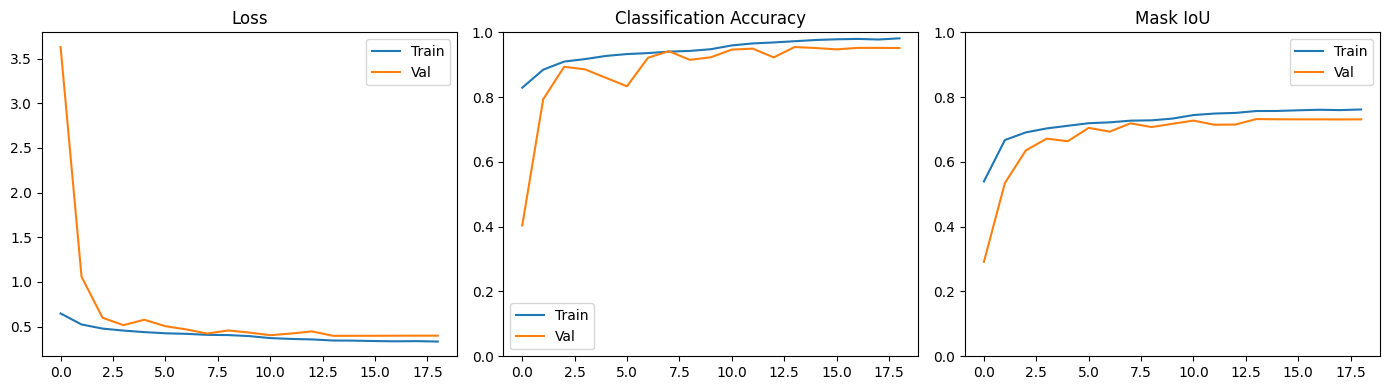

In [13]:
hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss
axes[0].plot(hist_df["loss"], label="Train")
axes[0].plot(hist_df["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].legend()

# Classification accuracy
axes[1].plot(hist_df["target_output_accuracy"], label="Train")
axes[1].plot(hist_df["val_target_output_accuracy"], label="Val")
axes[1].set_title("Classification Accuracy")
axes[1].legend()
axes[1].set_ylim(0, 1)

# Mask IoU — find columns by name
iou_train_col = [c for c in hist_df.columns if 'mask_output' in c and 'binary_io' in c and 'val' not in c]
iou_val_col   = [c for c in hist_df.columns if 'mask_output' in c and 'binary_io' in c and 'val' in c]
if iou_train_col and iou_val_col:
    axes[2].plot(hist_df[iou_train_col[0]], label="Train")
    axes[2].plot(hist_df[iou_val_col[0]], label="Val")
axes[2].set_title("Mask IoU")
axes[2].legend()
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 11. Evaluation on Test Set

In [14]:
test_results = model.evaluate(test_dataset, verbose=0)
test_metrics = dict(zip(model.metrics_names, test_results))
print("Test loss:", test_metrics.get("loss", "N/A"))
for name, val in test_metrics.items():
    if name != "loss":
        print(f"  {name}: {val:.4f}")

2026-06-21 22:10:46.953599: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 22:10:47.145833: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Test loss: 0.3909231424331665
  compile_metrics: 0.4899
  mask_output_loss: 0.1599
  target_output_loss: 0.7416


Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.95       886
   Pneumonia       0.95      0.90      0.93       601

    accuracy                           0.94      1487
   macro avg       0.94      0.93      0.94      1487
weighted avg       0.94      0.94      0.94      1487



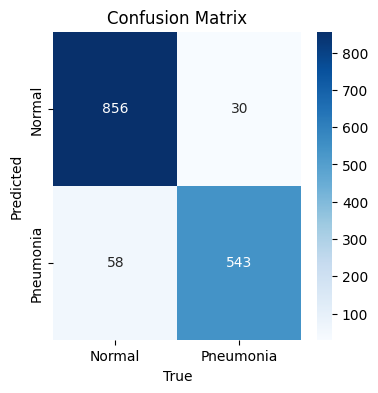

In [15]:
# Collect predictions
true_targets = []
pred_probs = []
for (_, _), (_, tgts) in test_dataset:
    true_targets.append(tgts.numpy())
true_targets = np.concatenate(true_targets)

pred_masks, pred_classes = model.predict(test_dataset, verbose=0)
pred_labels = (pred_classes > 0.5).astype(int).ravel()

print("Classification Report:")
print(classification_report(true_targets, pred_labels, target_names=["Normal", "Pneumonia"]))

# Confusion matrix
plt.figure(figsize=(4,4))
sns.heatmap(confusion_matrix(true_targets, pred_labels), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Pneumonia"], yticklabels=["Normal","Pneumonia"])
plt.title("Confusion Matrix")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [20]:
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, matthews_corrcoef, cohen_kappa_score

# Compute detailed metrics
pred_probs_flat = pred_classes.ravel() if pred_classes.ndim > 1 else pred_classes
true_flat = true_targets.ravel() if true_targets.ndim > 1 else true_targets
pred_binary = (pred_probs_flat > 0.5).astype(int)

print("--- Detailed Metrics ---")
print(f"F1 Score:           {f1_score(true_flat, pred_binary):.4f}")
print(f"Matthews Corr Coef: {matthews_corrcoef(true_flat, pred_binary):.4f}")
print(f"Cohen Kappa:        {cohen_kappa_score(true_flat, pred_binary):.4f}")
try:
    auroc = roc_auc_score(true_flat, pred_probs_flat)
    print(f"AUROC:              {auroc:.4f}")
except ValueError:
    print("AUROC:              N/A (single class in batch)")

# Per-class metrics
print("\n--- Per-Class Metrics ---")
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, supp = precision_recall_fscore_support(true_flat, pred_binary, labels=[0, 1])
print(f"{"Class":<10} {"Precision":<10} {"Recall":<10} {"F1":<10} {"Support":<10}")
print(f"{"Normal":<10} {prec[0]:<10.4f} {rec[0]:<10.4f} {f1[0]:<10.4f} {supp[0]:<10}")
print(f"{"Pneumonia":<10} {prec[1]:<10.4f} {rec[1]:<10.4f} {f1[1]:<10.4f} {supp[1]:<10}")

--- Detailed Metrics ---
F1 Score:           0.9250
Matthews Corr Coef: 0.8769
Cohen Kappa:        0.8762
AUROC:              0.9841

--- Per-Class Metrics ---
Class      Precision  Recall     F1         Support   
Normal     0.9365     0.9661     0.9511     886       
Pneumonia  0.9476     0.9035     0.9250     601       


Visualise some test predictions:

sample 0 | pred_mask min/max/mean: 0.0000/0.0000/0.0000 | true target: 0


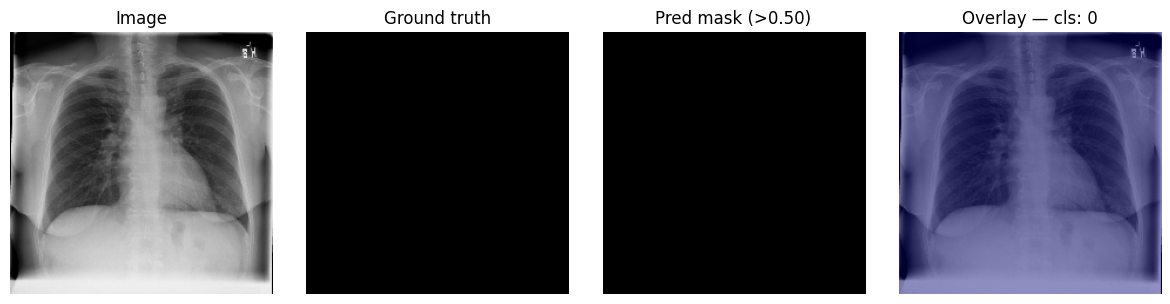

sample 1 | pred_mask min/max/mean: 0.0000/0.0000/0.0000 | true target: 0


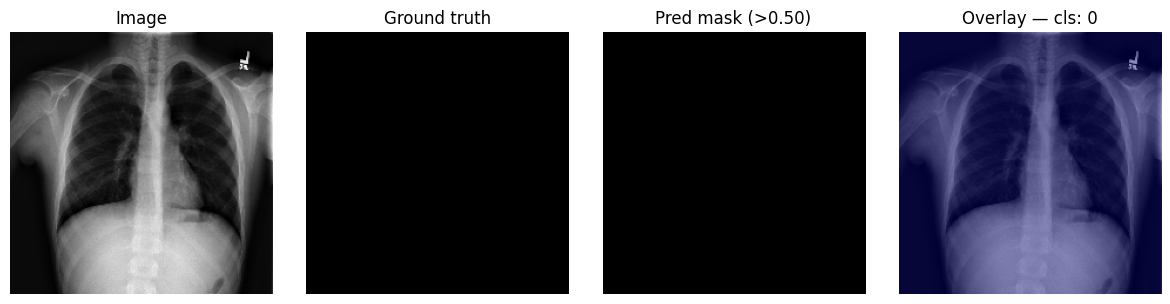

sample 2 | pred_mask min/max/mean: 0.0000/0.0000/0.0000 | true target: 1


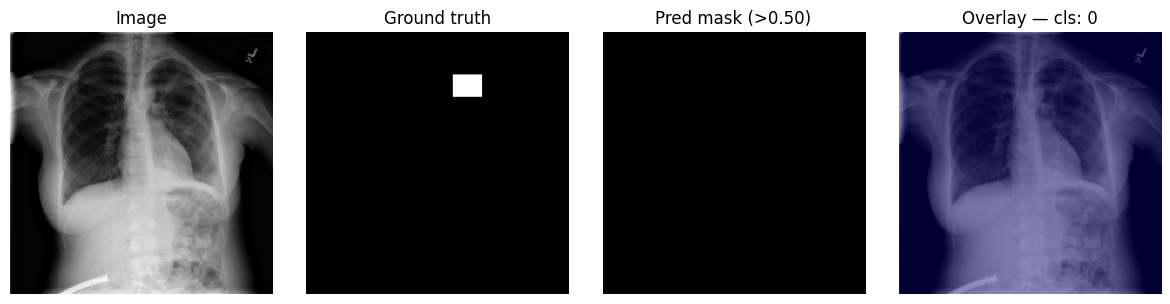

In [21]:
def visualize_predictions(dataset, model=None, n=5, threshold=0.5):
    for (imgs, var), (masks, tgts) in dataset.take(1): 
        for i in range(min(n, len(imgs))):
            pred_mask, pred_cls = model.predict(
                [imgs[i:i+1], var[i:i+1]],  
                verbose=0
            )
            bin_mask = (pred_mask[0] > threshold).astype(np.float32)

            print(f"sample {i} | pred_mask min/max/mean: "
                  f"{pred_mask.min():.4f}/{pred_mask.max():.4f}/{pred_mask.mean():.4f} "
                  f"| true target: {int(tgts[i].numpy())}") 

            plt.figure(figsize=(12, 3))

            plt.subplot(1, 4, 1)
            plt.imshow(imgs[i].numpy())
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1, 4, 2)
            plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
            plt.title("Ground truth")
            plt.axis("off")

            plt.subplot(1, 4, 3)
            plt.imshow(bin_mask.squeeze(), cmap="gray")
            plt.title(f"Pred mask (>{threshold:.2f})")
            plt.axis("off")

            plt.subplot(1, 4, 4)
            plt.imshow(imgs[i].numpy())
            plt.imshow(bin_mask.squeeze(), cmap="jet", alpha=0.4)
            plt.title(f"Overlay — cls: {int(pred_cls[0,0] > 0.5)}")
            plt.axis("off")

            plt.tight_layout()
            plt.show()


test_dataset_shuffled = test_dataset.shuffle(buffer_size=200)
visualize_predictions(test_dataset_shuffled, model=model, n=3)

## 12. Save Models

Two versions are saved:
1. **Full model** — requires both image and tabular inputs
2. **Inference model** — image-only (tabular inputs baked in with mean values); this is the one to use in the web app.

In [22]:
# 1. Full model
model.save(OUTPUT_DIR + "model_unet_full.keras")
print("Saved full model.")

# 2. Inference-only model (image input, tabular baked in with training mean)
mean_age   = float(df_train["age"].mean())
mean_sex   = float(df_train["sex"].mode().iloc[0] if not df_train["sex"].mode().empty else 0)
mean_pos   = float(df_train["position"].mode().iloc[0] if not df_train["position"].mode().empty else 0)
mean_vars  = tf.constant([[mean_age, mean_sex, mean_pos]], dtype=tf.float32)
print(f"Baked-in tabular values: age={mean_age:.3f}, sex={mean_sex}, position={mean_pos}")

# Create a wrapper model that only needs an image input
from keras.layers import Lambda
img_input = model.input[0]
tiled_vars = Lambda(lambda x: tf.tile(mean_vars, [tf.shape(x)[0], 1]), name="tile_vars")(img_input)
img_only_output = model([img_input, tiled_vars])
inference_model = Model(inputs=img_input, outputs=img_only_output, name="unet_inference")
inference_model.save(OUTPUT_DIR + "model_unet_inference.keras")
print("Saved inference model (image-only).")

Saved full model.
Baked-in tabular values: age=0.497, sex=0.0, position=1.0
Saved inference model (image-only).
